# DDRM inverse experiments

Same structure as the DPS notebook. Clones the repo, downloads one val shard and the EMA checkpoint, then runs DDRM for downsample and blur operators.

DDRM uses Fourier-basis correction for periodic Gaussian blur. For average downsample, the sampler uses stable block-mean projection to avoid amplifying aliased high frequencies.

Each operator has a configure cell and a run cell. The final cell concatenates all per-run CSVs.

In [1]:
from google.colab import drive
from pathlib import Path
import os

drive.mount("/content/drive")

REPO_DIR = Path("/content/drive/MyDrive/Skoltech/DL/Project/DL_final_project")  # поменяй путь под свой Drive

%cd "$REPO_DIR"
!pip install -q -r requirements.txt

Mounted at /content/drive
/content/drive/MyDrive/Skoltech/DL/Project/DL_final_project


In [2]:
# #@title 1. Clone repo and install dependencies
# from pathlib import Path
# import os

# REPO_URL = "https://github.com/SadreevAmir/DL_final_project.git"  #@param {type:"string"}
# REPO_DIR = Path("/content/DL_final_project")

# if not REPO_DIR.exists():
#     !git clone "$REPO_URL" "$REPO_DIR"
# else:
#     %cd "$REPO_DIR"
#     !git pull --ff-only

# %cd "$REPO_DIR"
# !pip install -q -r requirements.txt


In [3]:
#@title 2. Experiment settings
from pathlib import Path

DATA_SOURCE = "https://disk.yandex.ru/d/rrjDGzzX5cfFnA"  #@param {type:"string"}
EMA_CHECKPOINT_NAME = "best_score_vp_kolmogorov_velocity_256_to_64_coords_2ch_64x64_coords_bf16_20260517_221201_epoch_0014_val_0.028523_ema_model_only.pt"  #@param {type:"string"}
FULL_CHECKPOINT_NAME = "best_score_vp_kolmogorov_velocity_256_to_64_coords_2ch_64x64_coords_bf16_20260517_221201_epoch_0014_val_0.028523.pt"  #@param {type:"string"}
STATS_FILENAME = "kolmogorov_velocity_256_to_64_train_stats.json"  #@param {type:"string"}
VAL_SHARD_NAME = "val_000.npz"  #@param {type:"string"}

# How many val samples to use for metrics. 16 for debug, 256 for final.
METRIC_SAMPLE_COUNT = 16  #@param {type:"integer"}
SAMPLE_SEED = 0  #@param {type:"integer"}

# Keep fixed to make PNG visualizations reproducible across team members.
VISUALIZATION_SAMPLE_COUNT = 8  #@param {type:"integer"}
VISUALIZATION_SEED = 0  #@param {type:"integer"}
MAX_VISUALIZATIONS = VISUALIZATION_SAMPLE_COUNT  #@param {type:"integer"}

CORRUPTION_SEED = 0  #@param {type:"integer"}
NOISE_SIGMA = 0.0  #@param {type:"number"}
BLUR_SIGMA = 2.0  #@param {type:"number"}

# DDRM settings. Start with 64/128 for debug, then 256 for final runs.
DDRM_STEPS = 128  #@param {type:"integer"}
# A100 default. Reduce to 16 or 8 if OOM.
RUN_BATCH_SIZE = 16  #@param {type:"integer"}
CASE_BATCH_SIZE = 256  #@param {type:"integer"}
CASE_BUILD_DEVICE = "cuda"  #@param ["cpu", "cuda"]
DDRM_SEED = 0  #@param {type:"integer"}

# Per-operator eta and measurement_sigma are configured in each configure cell below.

CACHE_DIR = Path("data/one_val_cache")
FULL_VAL_CACHE_DIR = Path("data/full_val_cache")
CHECKPOINT_DIR = Path("checkpoints")
CASE_DIR = Path("inverse_cases")
RUNS_DIR = Path("runs_ddrm_colab")
WRAPPED_CHECKPOINT_PATH = CHECKPOINT_DIR / "wrapped_ema_checkpoint.pt"

# EMA-only checkpoints do not contain mean/std.
# Notebook tries STATS_FILENAME first, then full checkpoint data_stats.
DOWNLOAD_FULL_CHECKPOINT_FOR_STATS = True  #@param {type:"boolean"}
DELETE_FULL_CHECKPOINT_AFTER_STATS = False  #@param {type:"boolean"}
TRAIN_MEAN = None
TRAIN_STD = None


In [4]:
#@title 3. Imports and device
import json
import math
import urllib.parse
import urllib.request
from collections import deque

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm
from IPython.display import Image, display
import pandas as pd

from score_training import DiffusersUNet, VPCosineSDE
from inverse.cases import CaseConfig, create_case_file
from inverse.experiment import ExperimentConfig, run_experiment

torch.manual_seed(DDRM_SEED)
np.random.seed(DDRM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if device.type == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")


device: cuda
gpu: Tesla T4


In [5]:
#@title 4. Download one val shard and EMA checkpoint
def yandex_json(url: str) -> dict:
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req) as response:
        return json.loads(response.read().decode("utf-8"))


def yandex_list(public_key: str, path: str = "/") -> dict:
    params = {"public_key": public_key, "path": path, "limit": 1000}
    api_url = "https://cloud-api.yandex.net/v1/disk/public/resources?" + urllib.parse.urlencode(params)
    return yandex_json(api_url)


def find_public_path(public_key: str, filename: str) -> str:
    queue = deque(["/"])
    seen = set()
    while queue:
        path = queue.popleft()
        if path in seen:
            continue
        seen.add(path)
        payload = yandex_list(public_key, path)
        items = payload.get("_embedded", {}).get("items", [])
        for item in items:
            name = item.get("name", "")
            item_path = item.get("path", "")
            public_path = item_path.split(":", 1)[-1] if ":" in item_path else item_path
            if name == filename:
                return public_path
            if item.get("type") == "dir":
                queue.append(public_path)
    raise FileNotFoundError(f"Could not find {filename!r} in Yandex public folder")


def find_optional_public_path(public_key: str, filename: str) -> str | None:
    try:
        return find_public_path(public_key, filename)
    except FileNotFoundError:
        return None


def find_public_paths(public_key: str, predicate) -> list[str]:
    matches = []
    queue = deque(["/"])
    seen = set()
    while queue:
        path = queue.popleft()
        if path in seen:
            continue
        seen.add(path)
        payload = yandex_list(public_key, path)
        items = payload.get("_embedded", {}).get("items", [])
        for item in items:
            name = item.get("name", "")
            item_path = item.get("path", "")
            public_path = item_path.split(":", 1)[-1] if ":" in item_path else item_path
            if item.get("type") == "dir":
                queue.append(public_path)
            elif predicate(name):
                matches.append(public_path)
    return sorted(matches)


def yandex_download_href(public_key: str, path: str) -> str:
    params = {"public_key": public_key, "path": path}
    api_url = "https://cloud-api.yandex.net/v1/disk/public/resources/download?" + urllib.parse.urlencode(params)
    return yandex_json(api_url)["href"]


def download_file(url: str, target: Path, desc: str) -> Path:
    target.parent.mkdir(parents=True, exist_ok=True)
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req) as response:
        total = int(response.headers.get("Content-Length", 0))
        if target.exists() and (total <= 0 or target.stat().st_size == total):
            print("using cached:", target)
            return target
        with target.open("wb") as handle, tqdm(total=total or None, unit="B", unit_scale=True, desc=desc) as bar:
            while True:
                chunk = response.read(1024 * 1024)
                if not chunk:
                    break
                handle.write(chunk)
                bar.update(len(chunk))
    return target


val_public_path = find_public_path(DATA_SOURCE, VAL_SHARD_NAME)
ema_public_path = find_public_path(DATA_SOURCE, EMA_CHECKPOINT_NAME)
stats_public_path = find_optional_public_path(DATA_SOURCE, STATS_FILENAME)
full_public_path = find_optional_public_path(DATA_SOURCE, FULL_CHECKPOINT_NAME)
print("val path:", val_public_path)
print("EMA checkpoint path:", ema_public_path)
print("stats JSON path:", stats_public_path)
print("full checkpoint path:", full_public_path)

val_path = CACHE_DIR / VAL_SHARD_NAME
checkpoint_path = CHECKPOINT_DIR / EMA_CHECKPOINT_NAME
stats_path = CACHE_DIR / STATS_FILENAME if stats_public_path is not None else None
full_checkpoint_path = CHECKPOINT_DIR / FULL_CHECKPOINT_NAME if full_public_path is not None else None

download_file(yandex_download_href(DATA_SOURCE, val_public_path), val_path, VAL_SHARD_NAME)
download_file(yandex_download_href(DATA_SOURCE, ema_public_path), checkpoint_path, EMA_CHECKPOINT_NAME)
if stats_public_path is not None:
    download_file(yandex_download_href(DATA_SOURCE, stats_public_path), stats_path, STATS_FILENAME)
elif DOWNLOAD_FULL_CHECKPOINT_FOR_STATS and full_public_path is not None:
    download_file(yandex_download_href(DATA_SOURCE, full_public_path), full_checkpoint_path, FULL_CHECKPOINT_NAME)
else:
    print("WARNING: no standalone stats JSON and full-checkpoint download is disabled/unavailable.")

print("val shard:", val_path, f"{val_path.stat().st_size / 1024**2:.1f} MB")
print("EMA checkpoint:", checkpoint_path, f"{checkpoint_path.stat().st_size / 1024**2:.1f} MB")
if stats_path is not None and stats_path.exists():
    print("stats JSON:", stats_path, f"{stats_path.stat().st_size / 1024**2:.3f} MB")
if full_checkpoint_path is not None and full_checkpoint_path.exists():
    print("full checkpoint for stats:", full_checkpoint_path, f"{full_checkpoint_path.stat().st_size / 1024**2:.1f} MB")


val path: /val_000.npz
EMA checkpoint path: /best_score_vp_kolmogorov_velocity_256_to_64_coords_2ch_64x64_coords_bf16_20260517_221201_epoch_0014_val_0.028523_ema_model_only.pt
stats JSON path: None
full checkpoint path: /best_score_vp_kolmogorov_velocity_256_to_64_coords_2ch_64x64_coords_bf16_20260517_221201_epoch_0014_val_0.028523.pt
using cached: data/one_val_cache/val_000.npz
using cached: checkpoints/best_score_vp_kolmogorov_velocity_256_to_64_coords_2ch_64x64_coords_bf16_20260517_221201_epoch_0014_val_0.028523_ema_model_only.pt
using cached: checkpoints/best_score_vp_kolmogorov_velocity_256_to_64_coords_2ch_64x64_coords_bf16_20260517_221201_epoch_0014_val_0.028523.pt
val shard: data/one_val_cache/val_000.npz 156.4 MB
EMA checkpoint: checkpoints/best_score_vp_kolmogorov_velocity_256_to_64_coords_2ch_64x64_coords_bf16_20260517_221201_epoch_0014_val_0.028523_ema_model_only.pt 180.3 MB
full checkpoint for stats: checkpoints/best_score_vp_kolmogorov_velocity_256_to_64_coords_2ch_64x64_

In [6]:
#@title 5. Load val shard and prepare mean/std
with np.load(val_path) as arrays:
    print("keys:", list(arrays.keys()))
    val_images = arrays["images"].astype(np.float32, copy=False)
print("val images:", val_images.shape, val_images.dtype)

stats_source = "manual"
if TRAIN_MEAN is not None and TRAIN_STD is not None:
    mean = np.asarray(TRAIN_MEAN, dtype=np.float32)
    std = np.asarray(TRAIN_STD, dtype=np.float32)
elif stats_path is not None and stats_path.exists():
    stats_payload = json.loads(stats_path.read_text())
    mean = np.asarray(stats_payload["mean"], dtype=np.float32)
    std = np.asarray(stats_payload["std"], dtype=np.float32)
    stats_source = str(stats_path)
elif full_checkpoint_path is not None and full_checkpoint_path.exists():
    full_payload = torch.load(full_checkpoint_path, map_location="cpu", weights_only=False)
    if "data_stats" not in full_payload:
        raise RuntimeError(f"Full checkpoint {full_checkpoint_path} does not contain data_stats")
    stats_payload = full_payload["data_stats"]
    mean = np.asarray(stats_payload["mean"], dtype=np.float32)
    std = np.asarray(stats_payload["std"], dtype=np.float32)
    stats_source = f"{full_checkpoint_path}:data_stats"
    if DELETE_FULL_CHECKPOINT_AFTER_STATS:
        full_checkpoint_path.unlink()
        print("deleted full checkpoint after extracting stats:", full_checkpoint_path)
else:
    print("WARNING: using stats from val_000. Only for smoke tests, not final metrics.")
    mean = val_images.mean(axis=(0, 2, 3), dtype=np.float64).astype(np.float32)
    std = val_images.std(axis=(0, 2, 3), dtype=np.float64).astype(np.float32)
    stats_source = f"{val_path}:computed_val_fallback"

std = np.maximum(std, 1.0e-6)
print("stats source:", stats_source)
print("mean:", mean)
print("std:", std)


keys: ['images', 'trajectory_id', 'snapshot_index', 'step', 'viscosity', 'drag', 'forcing_amp', 'split']
val images: (5000, 2, 64, 64) float32
stats source: checkpoints/best_score_vp_kolmogorov_velocity_256_to_64_coords_2ch_64x64_coords_bf16_20260517_221201_epoch_0014_val_0.028523.pt:data_stats
mean: [1.7451093e-12 2.7684701e-12]
std: [0.43831408 0.4253821 ]


In [7]:
#@title 6. Wrap EMA-only checkpoint into shared pipeline format
CHANNELS = 2
IMAGE_SIZE = 64
COORDINATE_MODE = "fourier"
CHANNELS_PER_LEVEL = "96,192,384"
NUM_RES_BLOCKS = 3
ATTENTION_HEAD_DIM = 32
PADDING_MODE = "circular"
TIME_EMBEDDING_SCALE = 999.0
CLIP_PRED_X0 = 5.0

state = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
if isinstance(state, dict) and "ema_model" in state:
    state = state["ema_model"]
config = {
    "channels_per_level": CHANNELS_PER_LEVEL,
    "num_res_blocks": NUM_RES_BLOCKS,
    "attention_head_dim": ATTENTION_HEAD_DIM,
    "padding_mode": PADDING_MODE,
    "coordinate_mode": COORDINATE_MODE,
    "time_embedding_scale": TIME_EMBEDDING_SCALE,
    "clip_pred_x0": CLIP_PRED_X0,
    "sample_steps": DDRM_STEPS,
    "dropout": 0.0,
}
data_stats = {
    "mean": [float(x) for x in mean],
    "std": [float(x) for x in std],
    "channels": CHANNELS,
    "height": IMAGE_SIZE,
    "width": IMAGE_SIZE,
    "train_count": 0,
    "val_count": int(val_images.shape[0]),
    "source": str(val_path),
    "stats_source": stats_source,
}
wrapped = {
    "ema_model": state,
    "config": config,
    "data_stats": data_stats,
    "coordinate_mode": COORDINATE_MODE,
    "time_embedding_scale": TIME_EMBEDDING_SCALE,
}
WRAPPED_CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save(wrapped, WRAPPED_CHECKPOINT_PATH)
print("wrapped checkpoint:", WRAPPED_CHECKPOINT_PATH)


wrapped checkpoint: checkpoints/wrapped_ema_checkpoint.pt


In [8]:
#@title 7. Shared run helper
all_metrics_by_run = {}


def _safe_tag(value) -> str:
    return str(value).replace(".", "p").replace("-", "m")


def run_ddrm_experiment(
    operator_name: str,
    run_specs: list[dict],
    metric_sample_count: int | None = None,
    visualization_sample_count: int | None = None,
    max_visualizations: int | None = None,
    sample_seed: int | None = None,
    visualization_seed: int | None = None,
    corruption_seed: int | None = None,
    noise_sigma: float | None = None,
    blur_sigma: float | None = None,
    steps: int | None = None,
    run_batch_size: int | None = None,
    case_batch_size: int | None = None,
    display_max_images: int | None = None,
    data_source_dir: Path | str | None = None,
    data_tag: str = "",
):
    metric_sample_count = METRIC_SAMPLE_COUNT if metric_sample_count is None else metric_sample_count
    visualization_sample_count = VISUALIZATION_SAMPLE_COUNT if visualization_sample_count is None else visualization_sample_count
    max_visualizations = MAX_VISUALIZATIONS if max_visualizations is None else max_visualizations
    sample_seed = SAMPLE_SEED if sample_seed is None else sample_seed
    visualization_seed = VISUALIZATION_SEED if visualization_seed is None else visualization_seed
    corruption_seed = CORRUPTION_SEED if corruption_seed is None else corruption_seed
    noise_sigma = NOISE_SIGMA if noise_sigma is None else noise_sigma
    blur_sigma = BLUR_SIGMA if blur_sigma is None else blur_sigma
    steps = DDRM_STEPS if steps is None else steps
    run_batch_size = RUN_BATCH_SIZE if run_batch_size is None else run_batch_size
    case_batch_size = CASE_BATCH_SIZE if case_batch_size is None else case_batch_size
    display_max_images = max_visualizations * len(run_specs) if display_max_images is None else display_max_images
    data_source_dir = CACHE_DIR if data_source_dir is None else Path(data_source_dir)
    sample_tag = "all" if int(metric_sample_count) <= 0 else str(int(metric_sample_count))
    source_suffix = f"_{data_tag}" if data_tag else ""
    blur_suffix = f"_blur{_safe_tag(blur_sigma)}" if operator_name == "blur" else ""
    case_path = CASE_DIR / f"{operator_name}{blur_suffix}{source_suffix}_val{sample_tag}_vis{visualization_sample_count}_seed{sample_seed}.npz"
    cfg = CaseConfig(
        data_source=str(data_source_dir),
        output_path=str(case_path),
        operator=operator_name,
        split="val",
        num_samples=metric_sample_count,
        sample_seed=sample_seed,
        visualization_count=visualization_sample_count,
        visualization_seed=visualization_seed,
        corruption_seed=corruption_seed,
        noise_sigma=noise_sigma,
        blur_sigma=blur_sigma,
        device=CASE_BUILD_DEVICE if (CASE_BUILD_DEVICE == "cpu" or torch.cuda.is_available()) else "cpu",
        case_batch_size=case_batch_size,
    )
    case_path = create_case_file(cfg)
    print("case:", case_path)

    local_metrics_paths = []
    local_output_dirs = []
    for spec in run_specs:
        eta = float(spec.get("eta", 0.85))
        measurement_sigma = float(spec.get("measurement_sigma", 0.0))
        physics_projection = bool(spec.get("physics_projection", False))
        label = spec.get("label", "ddrm_phys" if physics_projection else "ddrm")
        tag = f"{label}_{operator_name}{source_suffix}_eta{_safe_tag(eta)}_n{sample_tag}_steps{steps}"
        if operator_name == "blur":
            tag += f"_sigma{_safe_tag(blur_sigma)}"
        output_dir = RUNS_DIR / tag
        exp_cfg = ExperimentConfig(
            checkpoint_path=str(WRAPPED_CHECKPOINT_PATH),
            case_file=str(case_path),
            output_dir=str(output_dir),
            method="ddrm",
            device="auto",
            batch_size=run_batch_size,
            steps=steps,
            seed=DDRM_SEED,
            max_visualizations=max_visualizations,
            visualization_sample_count=max_visualizations,
            eta=eta,
            measurement_sigma=measurement_sigma,
            physics_projection=physics_projection,
        )
        print("running:", output_dir)
        metrics_path = run_experiment(exp_cfg)
        local_metrics_paths.append(metrics_path)
        local_output_dirs.append(output_dir)
        all_metrics_by_run[str(output_dir)] = metrics_path
        figure_count = len(list((output_dir / "figures").glob("*.png")))
        print("saved metrics:", metrics_path)
        print("saved figures:", figure_count, "in", output_dir / "figures")

    frames = []
    for path in local_metrics_paths:
        df = pd.read_csv(path)
        df["run"] = str(path.parent)
        frames.append(df)
    local_metrics = pd.concat(frames, ignore_index=True)
    local_out = RUNS_DIR / f"{operator_name}{blur_suffix}{source_suffix}_metrics.csv"
    local_metrics.to_csv(local_out, index=False)
    group_cols = [col for col in ["method_variant", "method", "physics_informed", "physics_projection", "operator", "run"] if col in local_metrics.columns]
    local_summary = local_metrics.groupby(group_cols)[["rel_l2", "rmse", "measurement_error", "divergence", "vorticity_rmse"]].mean().reset_index()
    display(local_summary)
    print("operator csv:", local_out)

    if all_metrics_by_run:
        cumulative_frames = []
        for run_path in all_metrics_by_run.values():
            df = pd.read_csv(run_path)
            df["run"] = str(run_path.parent)
            cumulative_frames.append(df)
        cumulative_metrics = pd.concat(cumulative_frames, ignore_index=True)
        RUNS_DIR.mkdir(parents=True, exist_ok=True)
        cumulative_csv = RUNS_DIR / "all_metrics.csv"
        cumulative_metrics.to_csv(cumulative_csv, index=False)
        cumulative_group_cols = [col for col in ["method_variant", "method", "physics_informed", "physics_projection", "operator", "run"] if col in cumulative_metrics.columns]
        cumulative_summary = cumulative_metrics.groupby(cumulative_group_cols)[["rel_l2", "rmse", "measurement_error", "divergence", "vorticity_rmse"]].mean().reset_index()
        cumulative_summary_csv = RUNS_DIR / "summary.csv"
        cumulative_summary.to_csv(cumulative_summary_csv, index=False)
        print("cumulative metrics:", cumulative_csv)
        print("cumulative summary:", cumulative_summary_csv)

    figure_paths = []
    for output_dir in local_output_dirs:
        figure_paths.extend(sorted((output_dir / "figures").glob("*.png")))
    print("displaying figures:", min(len(figure_paths), display_max_images), "of", len(figure_paths))
    for path in figure_paths[:display_max_images]:
        print(path)
        display(Image(filename=str(path)))
    return local_metrics_paths


In [9]:
#@title Configure downsample run
# DDRM primary operator: downsample 64x64 -> 16x16.
# Average downsampling uses stable block-mean projection rather than Fourier deconvolution.
# eta: stochasticity per step. 1.0 = full DDPM noise, 0.0 = deterministic DDIM-like.
# physics_projection: apply Helmholtz div-free projection to pred_x0 after DDRM update.
DOWN_METRIC_SAMPLE_COUNT = METRIC_SAMPLE_COUNT  #@param {type:"integer"}
DOWN_VISUALIZATION_SAMPLE_COUNT = VISUALIZATION_SAMPLE_COUNT  #@param {type:"integer"}
DOWN_MAX_VISUALIZATIONS = min(MAX_VISUALIZATIONS, DOWN_VISUALIZATION_SAMPLE_COUNT)  #@param {type:"integer"}
DOWN_RUN_BATCH_SIZE = RUN_BATCH_SIZE  #@param {type:"integer"}
DOWN_DDRM_STEPS = DDRM_STEPS  #@param {type:"integer"}
DOWN_CORRUPTION_SEED = CORRUPTION_SEED  #@param {type:"integer"}
DOWN_NOISE_SIGMA = NOISE_SIGMA  #@param {type:"number"}
DOWN_ETA = 0.0  #@param {type:"number"}
DOWN_PHYS_ETA = 0.0  #@param {type:"number"}
DOWN_MEASUREMENT_SIGMA = 0.0  #@param {type:"number"}
RUN_PHYSICS_VARIANTS = False  #@param {type:"boolean"}
DOWN_RUNS = [
    {"label": "ddrm", "eta": DOWN_ETA, "measurement_sigma": DOWN_MEASUREMENT_SIGMA, "physics_projection": False},
    *([{"label": "ddrm_phys", "eta": DOWN_PHYS_ETA, "measurement_sigma": DOWN_MEASUREMENT_SIGMA, "physics_projection": True}] if RUN_PHYSICS_VARIANTS else []),
]
DOWN_RUNS


[{'label': 'ddrm',
  'eta': 0.0,
  'measurement_sigma': 0.0,
  'physics_projection': False}]

case: inverse_cases/downsample_val16_vis8_seed0.npz
running: runs_ddrm_colab/ddrm_downsample_eta0p0_n16_steps128


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


ddrm:downsample:   0%|          | 0/1 [00:00<?, ?batch/s]

saved metrics: runs_ddrm_colab/ddrm_downsample_eta0p0_n16_steps128/metrics.csv
saved figures: 8 in runs_ddrm_colab/ddrm_downsample_eta0p0_n16_steps128/figures


,method_variant,method,physics_informed,physics_projection,operator,run,rel_l2,rmse,measurement_error,divergence,vorticity_rmse
0,ddrm,ddrm,0,0,downsample,runs_ddrm_colab/ddrm_downsample_eta0p0_n16_ste...,0.065514,0.024708,0.000032,0.019684,0.043141


operator csv: runs_ddrm_colab/downsample_metrics.csv
cumulative metrics: runs_ddrm_colab/all_metrics.csv
cumulative summary: runs_ddrm_colab/summary.csv
displaying figures: 8 of 8
runs_ddrm_colab/ddrm_downsample_eta0p0_n16_steps128/figures/0000_traj1659_snap47.png


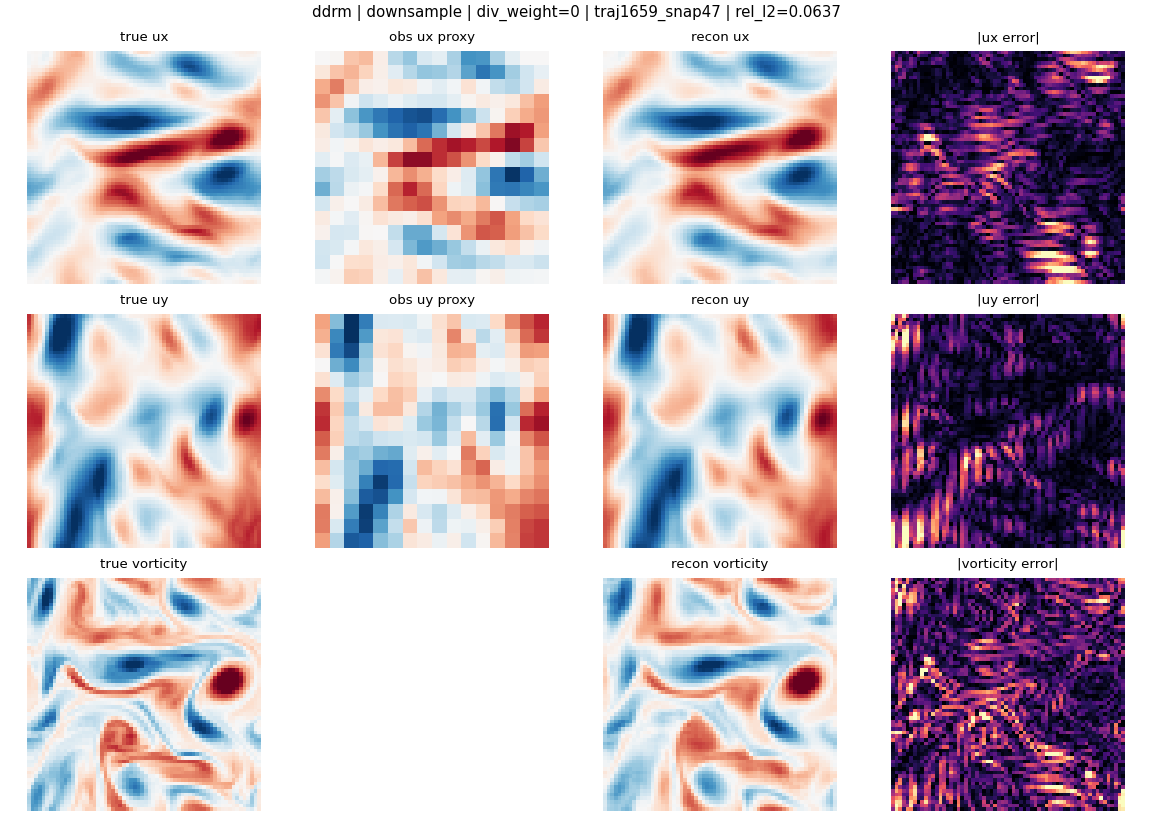

runs_ddrm_colab/ddrm_downsample_eta0p0_n16_steps128/figures/0001_traj1717_snap6.png


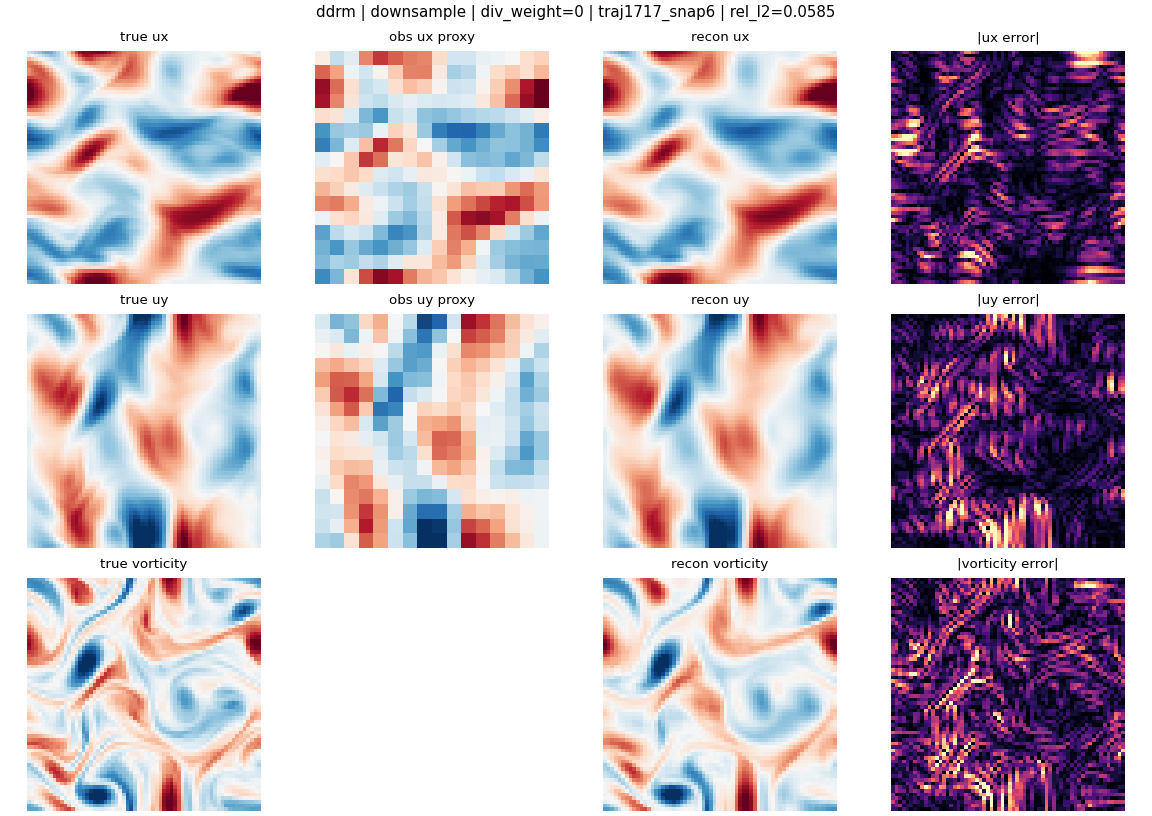

runs_ddrm_colab/ddrm_downsample_eta0p0_n16_steps128/figures/0002_traj1691_snap5.png


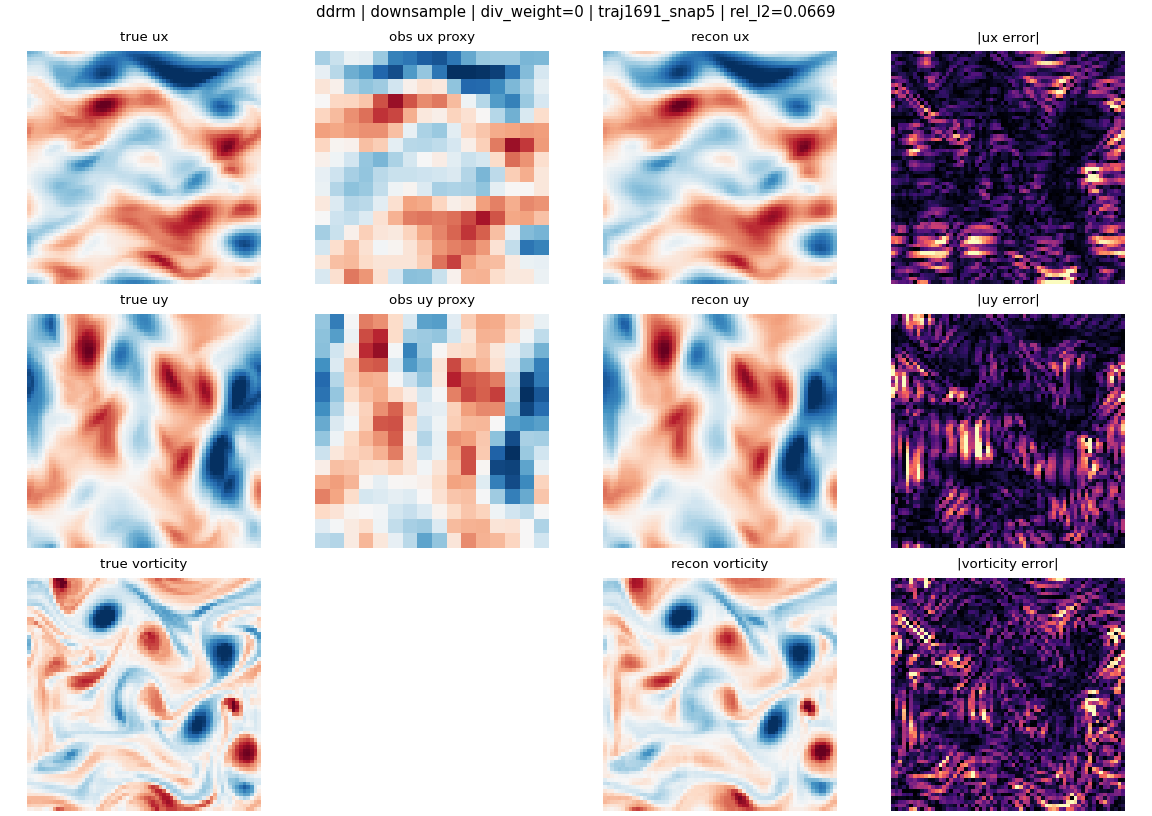

runs_ddrm_colab/ddrm_downsample_eta0p0_n16_steps128/figures/0003_traj1672_snap19.png


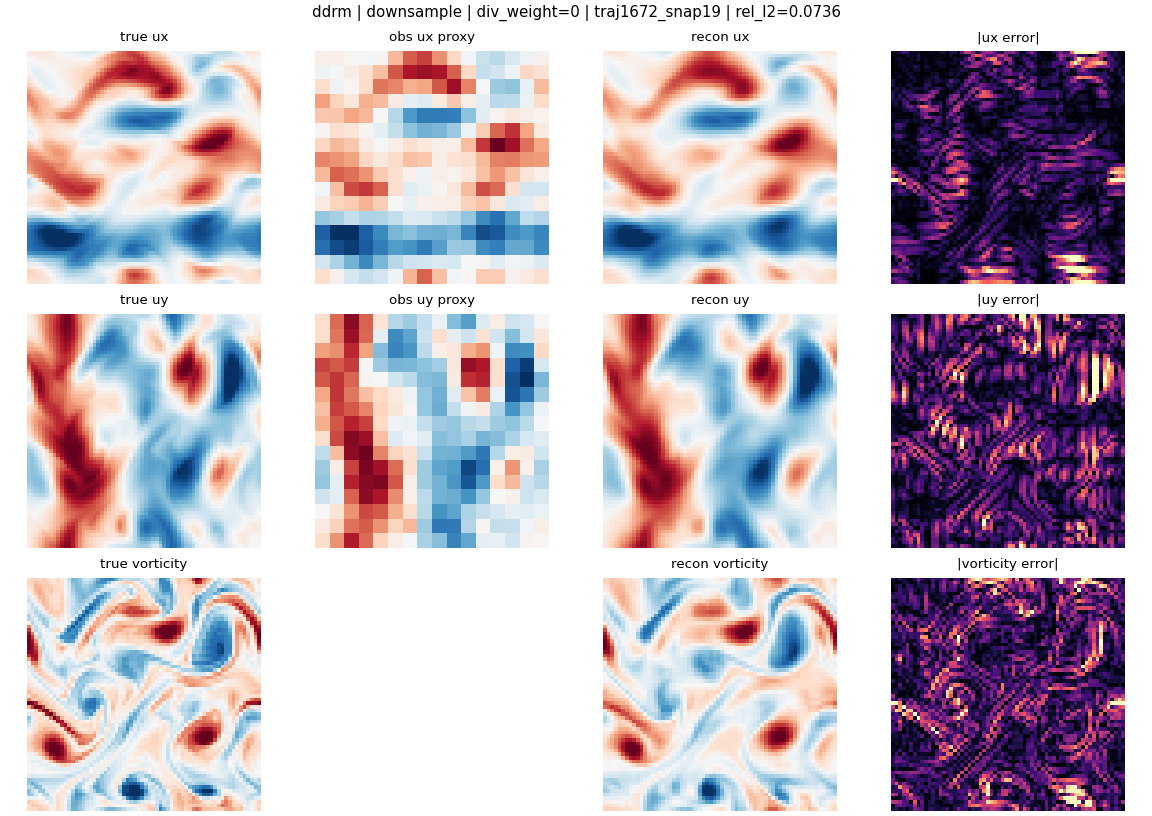

runs_ddrm_colab/ddrm_downsample_eta0p0_n16_steps128/figures/0004_traj1672_snap22.png


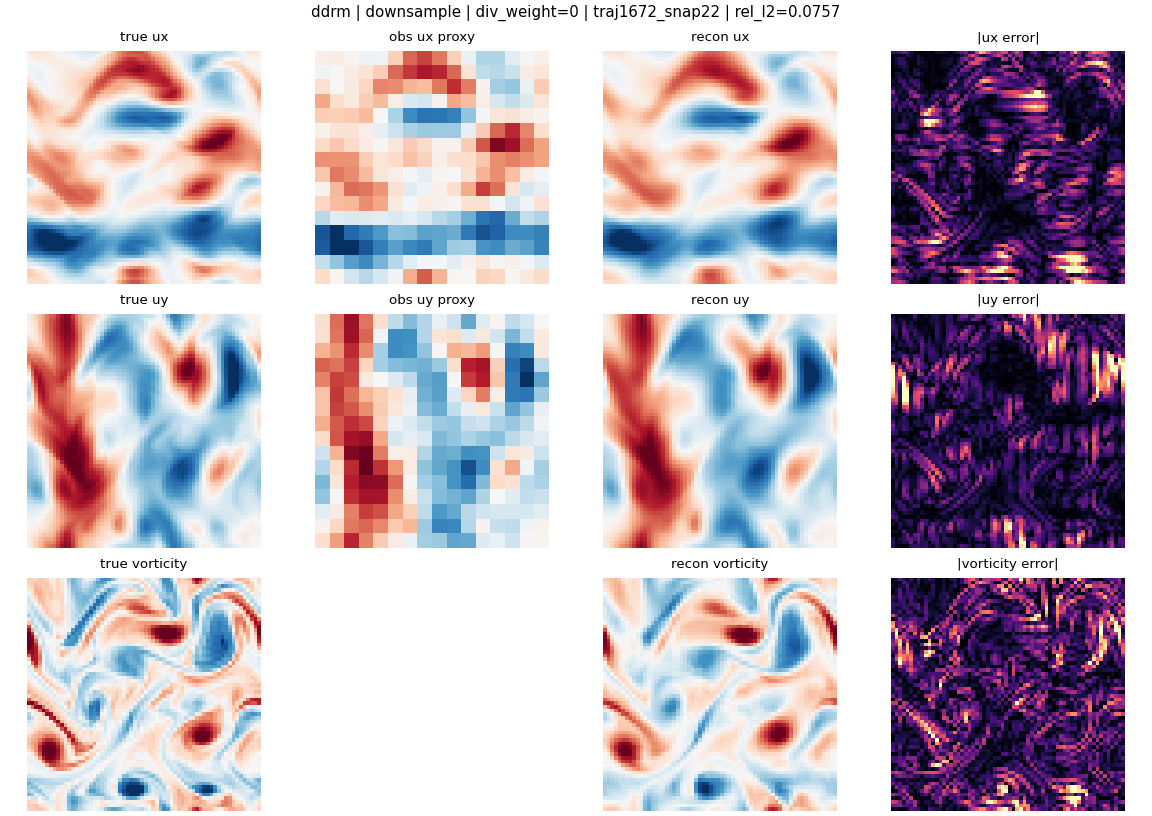

runs_ddrm_colab/ddrm_downsample_eta0p0_n16_steps128/figures/0005_traj1650_snap15.png


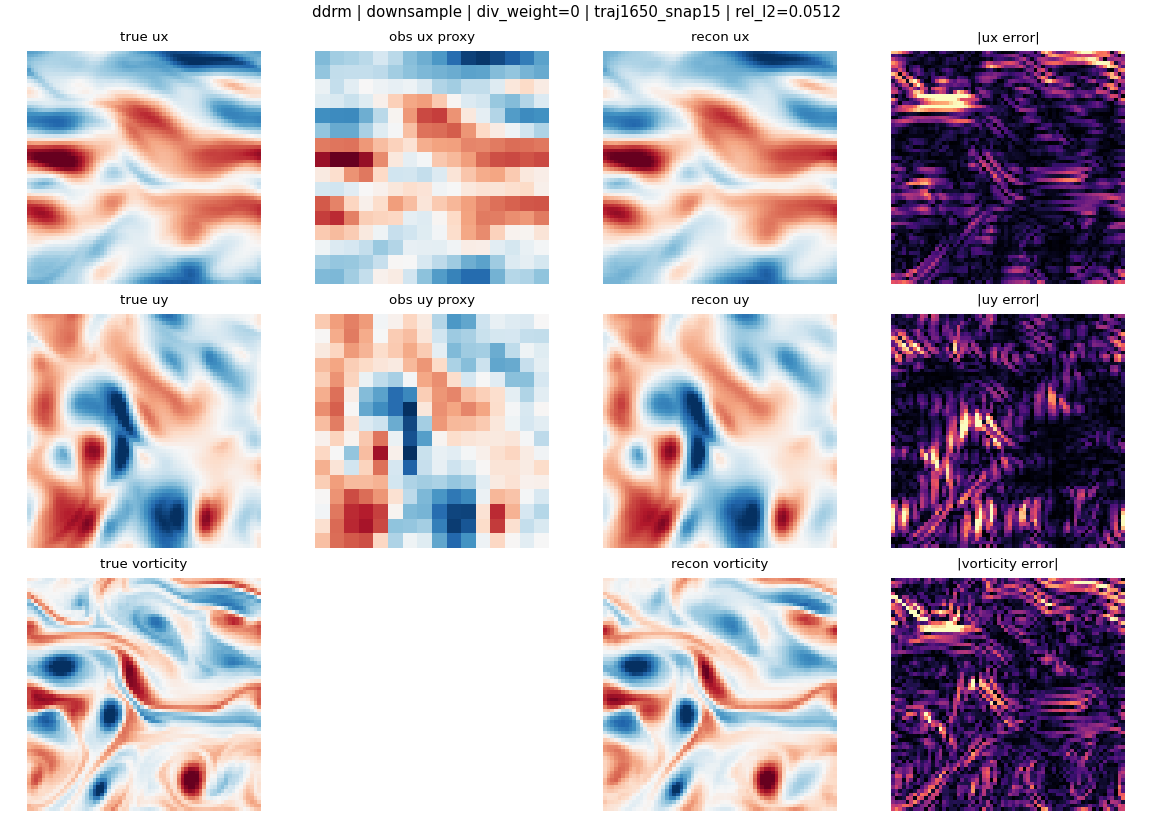

runs_ddrm_colab/ddrm_downsample_eta0p0_n16_steps128/figures/0006_traj1713_snap12.png


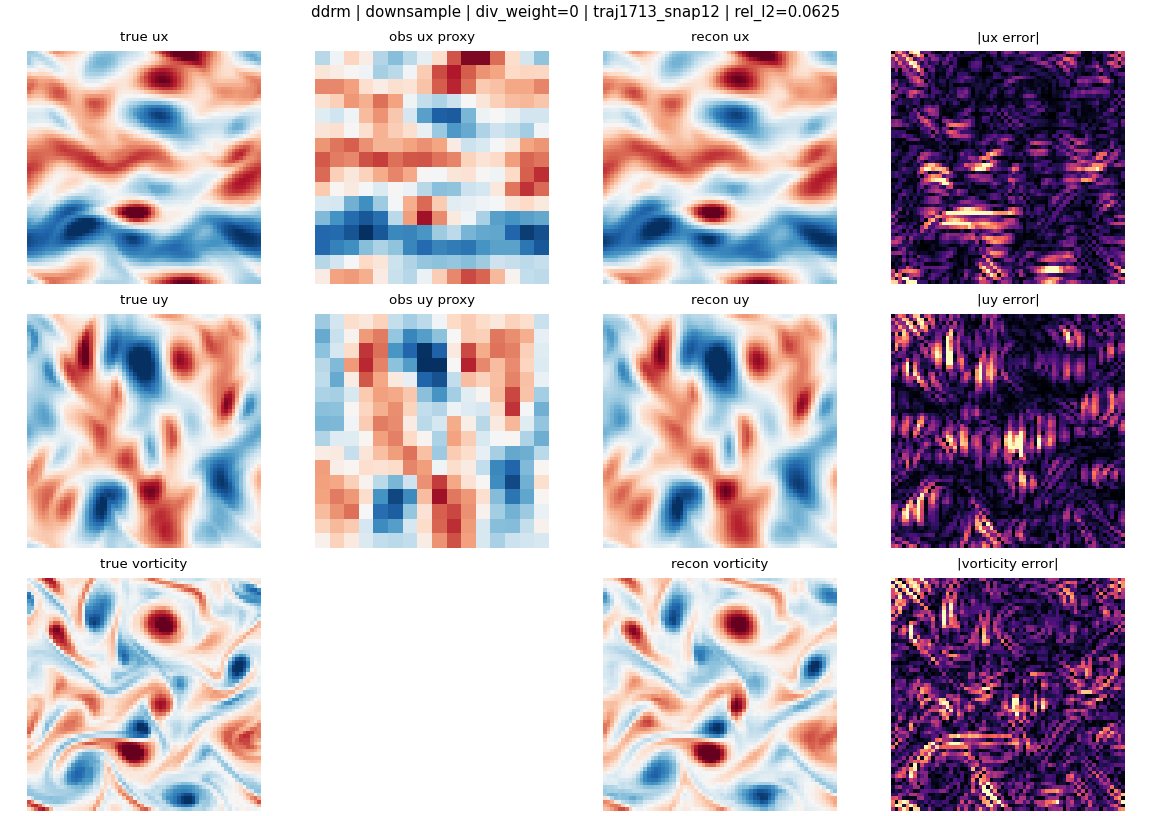

runs_ddrm_colab/ddrm_downsample_eta0p0_n16_steps128/figures/0007_traj1651_snap33.png


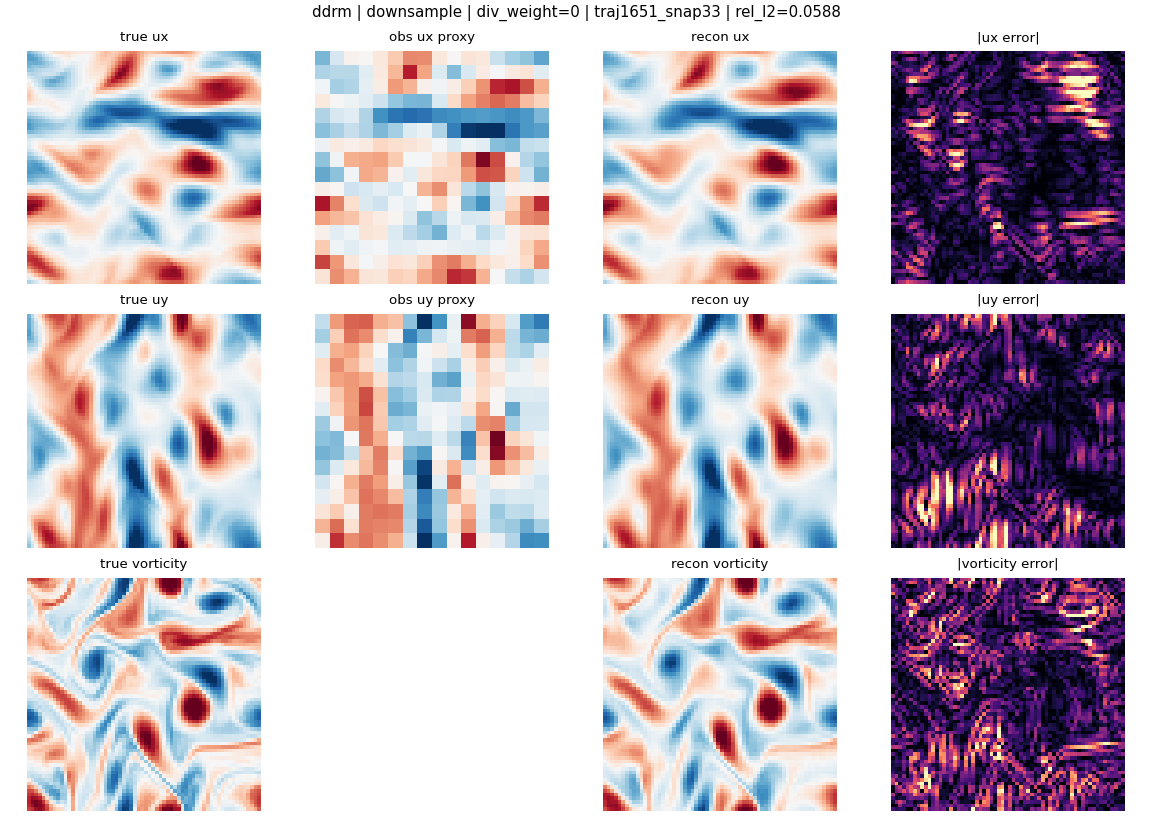

In [10]:
#@title Run downsample observation
downsample_metrics_paths = run_ddrm_experiment(
    "downsample",
    DOWN_RUNS,
    metric_sample_count=DOWN_METRIC_SAMPLE_COUNT,
    visualization_sample_count=DOWN_VISUALIZATION_SAMPLE_COUNT,
    max_visualizations=DOWN_MAX_VISUALIZATIONS,
    corruption_seed=DOWN_CORRUPTION_SEED,
    noise_sigma=DOWN_NOISE_SIGMA,
    steps=DOWN_DDRM_STEPS,
    run_batch_size=DOWN_RUN_BATCH_SIZE,
)


In [11]:
#@title Configure blur run
# DDRM second primary operator: periodic Gaussian blur.
# Blur diagonalizes exactly in the Fourier basis as pointwise multiplication by H(k).
# measurement_sigma > 0 handles noisy observations: larger sigma -> softer spectral correction.
BLUR_METRIC_SAMPLE_COUNT = METRIC_SAMPLE_COUNT  #@param {type:"integer"}
BLUR_VISUALIZATION_SAMPLE_COUNT = VISUALIZATION_SAMPLE_COUNT  #@param {type:"integer"}
BLUR_MAX_VISUALIZATIONS = min(MAX_VISUALIZATIONS, BLUR_VISUALIZATION_SAMPLE_COUNT)  #@param {type:"integer"}
BLUR_RUN_BATCH_SIZE = RUN_BATCH_SIZE  #@param {type:"integer"}
BLUR_DDRM_STEPS = DDRM_STEPS  #@param {type:"integer"}
BLUR_CORRUPTION_SEED = CORRUPTION_SEED  #@param {type:"integer"}
BLUR_NOISE_SIGMA = NOISE_SIGMA  #@param {type:"number"}
BLUR_OBS_SIGMA = BLUR_SIGMA  #@param {type:"number"}
BLUR_ETA = 0.0  #@param {type:"number"}
BLUR_PHYS_ETA = 0.0  #@param {type:"number"}
BLUR_MEASUREMENT_SIGMA = 0.0  #@param {type:"number"}
BLUR_RUNS = [
    {"label": "ddrm", "eta": BLUR_ETA, "measurement_sigma": BLUR_MEASUREMENT_SIGMA, "physics_projection": False},
    *([{"label": "ddrm_phys", "eta": BLUR_PHYS_ETA, "measurement_sigma": BLUR_MEASUREMENT_SIGMA, "physics_projection": True}] if RUN_PHYSICS_VARIANTS else []),
]
BLUR_RUNS


[{'label': 'ddrm',
  'eta': 0.0,
  'measurement_sigma': 0.0,
  'physics_projection': False}]

case: inverse_cases/blur_blur2p0_val16_vis8_seed0.npz
running: runs_ddrm_colab/ddrm_blur_eta0p0_n16_steps128_sigma2p0


ddrm:blur:   0%|          | 0/1 [00:00<?, ?batch/s]

saved metrics: runs_ddrm_colab/ddrm_blur_eta0p0_n16_steps128_sigma2p0/metrics.csv
saved figures: 8 in runs_ddrm_colab/ddrm_blur_eta0p0_n16_steps128_sigma2p0/figures


,method_variant,method,physics_informed,physics_projection,operator,run,rel_l2,rmse,measurement_error,divergence,vorticity_rmse
0,ddrm,ddrm,0,0,blur,runs_ddrm_colab/ddrm_blur_eta0p0_n16_steps128_...,0.049399,0.018447,0.00002,0.130881,0.054274


operator csv: runs_ddrm_colab/blur_blur2p0_metrics.csv
cumulative metrics: runs_ddrm_colab/all_metrics.csv
cumulative summary: runs_ddrm_colab/summary.csv
displaying figures: 8 of 8
runs_ddrm_colab/ddrm_blur_eta0p0_n16_steps128_sigma2p0/figures/0000_traj1659_snap47.png


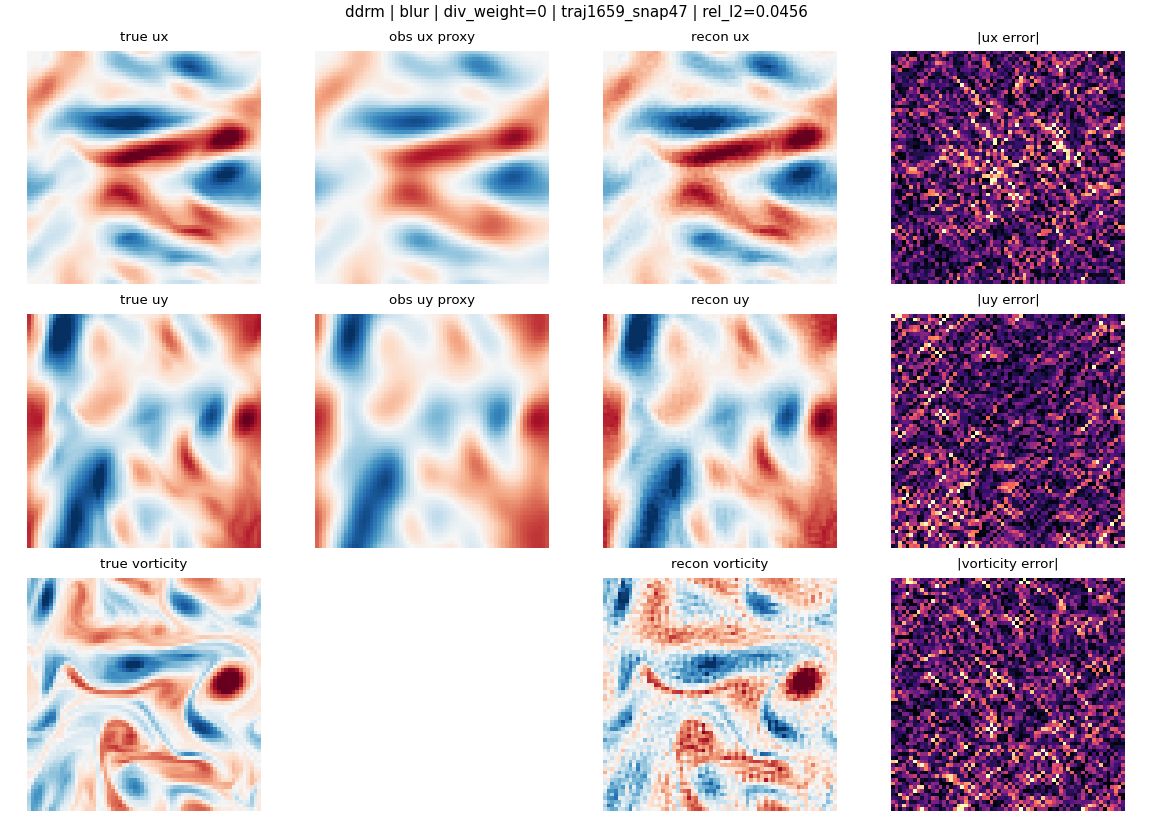

runs_ddrm_colab/ddrm_blur_eta0p0_n16_steps128_sigma2p0/figures/0001_traj1717_snap6.png


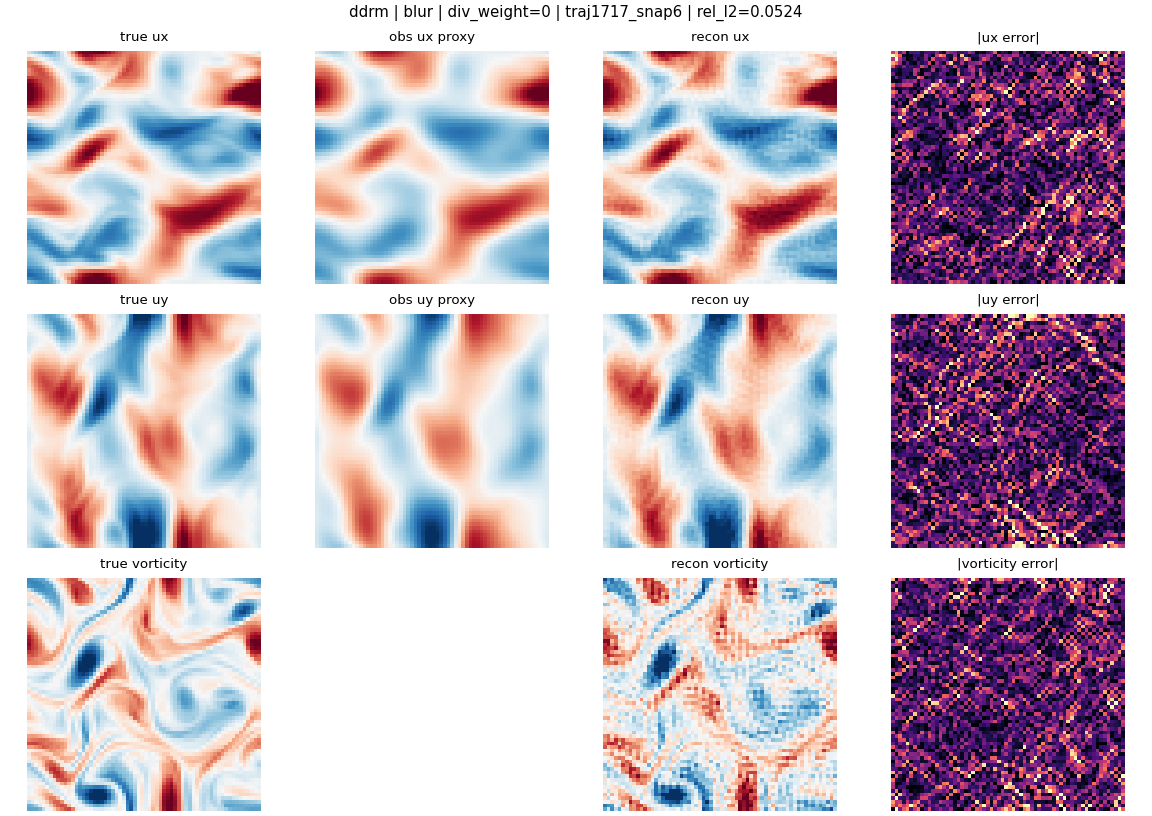

runs_ddrm_colab/ddrm_blur_eta0p0_n16_steps128_sigma2p0/figures/0002_traj1691_snap5.png


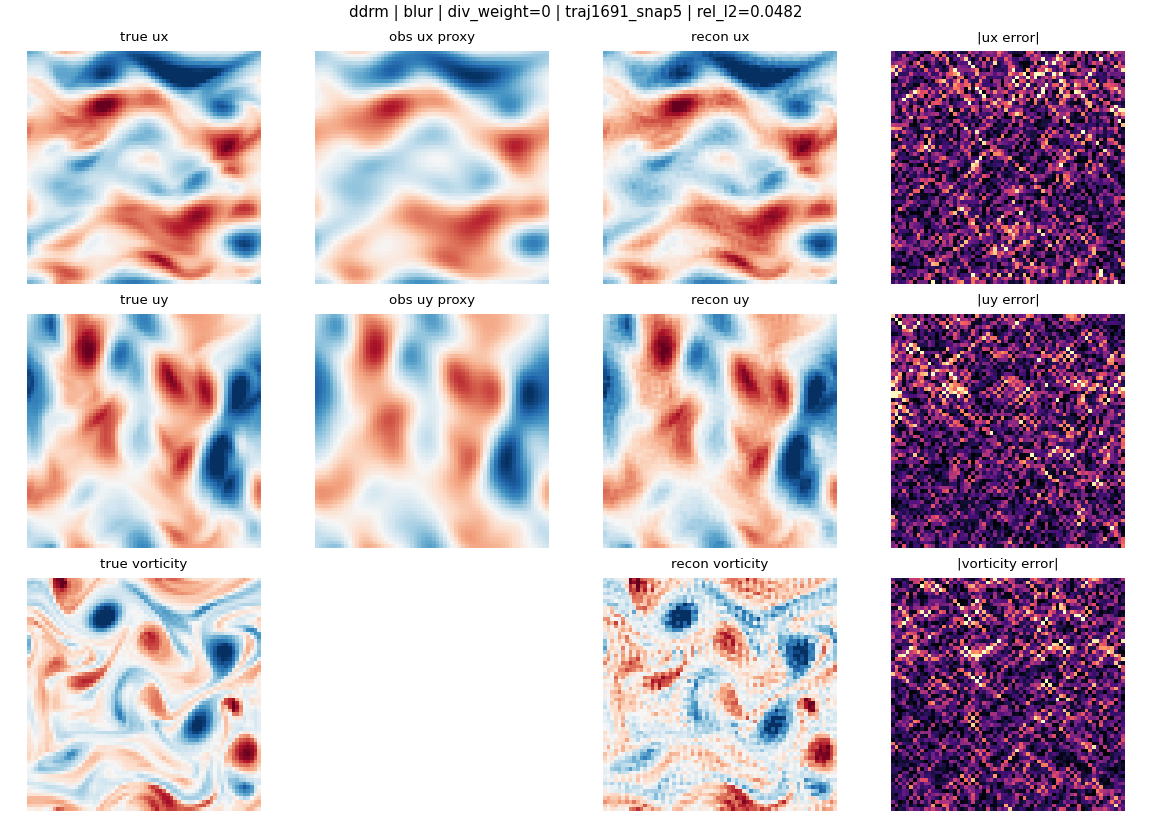

runs_ddrm_colab/ddrm_blur_eta0p0_n16_steps128_sigma2p0/figures/0003_traj1672_snap19.png


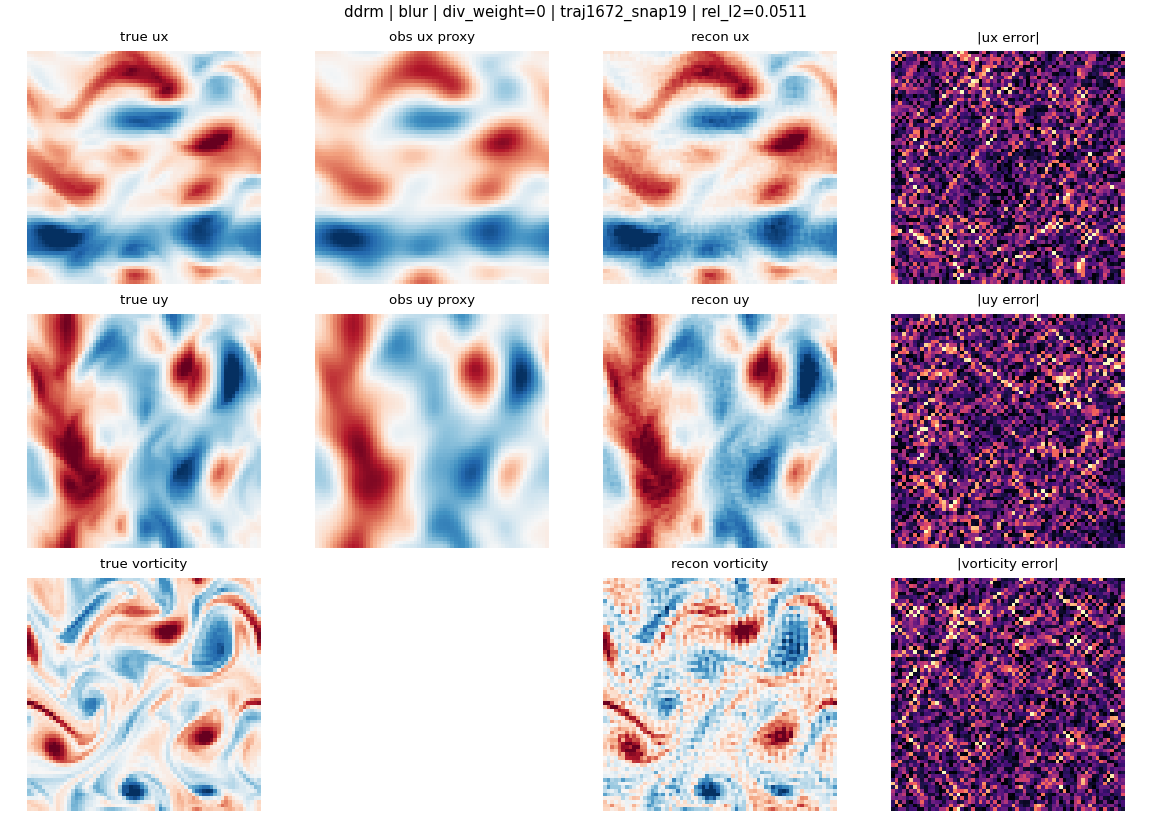

runs_ddrm_colab/ddrm_blur_eta0p0_n16_steps128_sigma2p0/figures/0004_traj1672_snap22.png


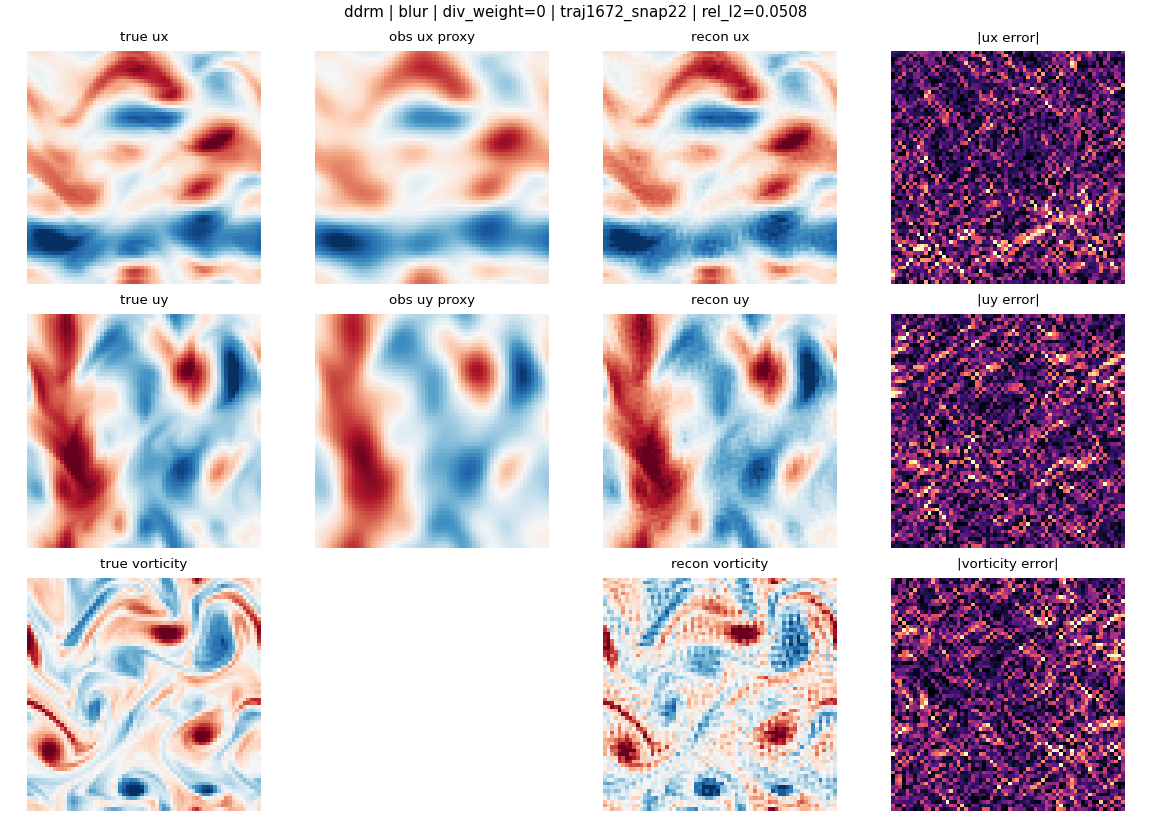

runs_ddrm_colab/ddrm_blur_eta0p0_n16_steps128_sigma2p0/figures/0005_traj1650_snap15.png


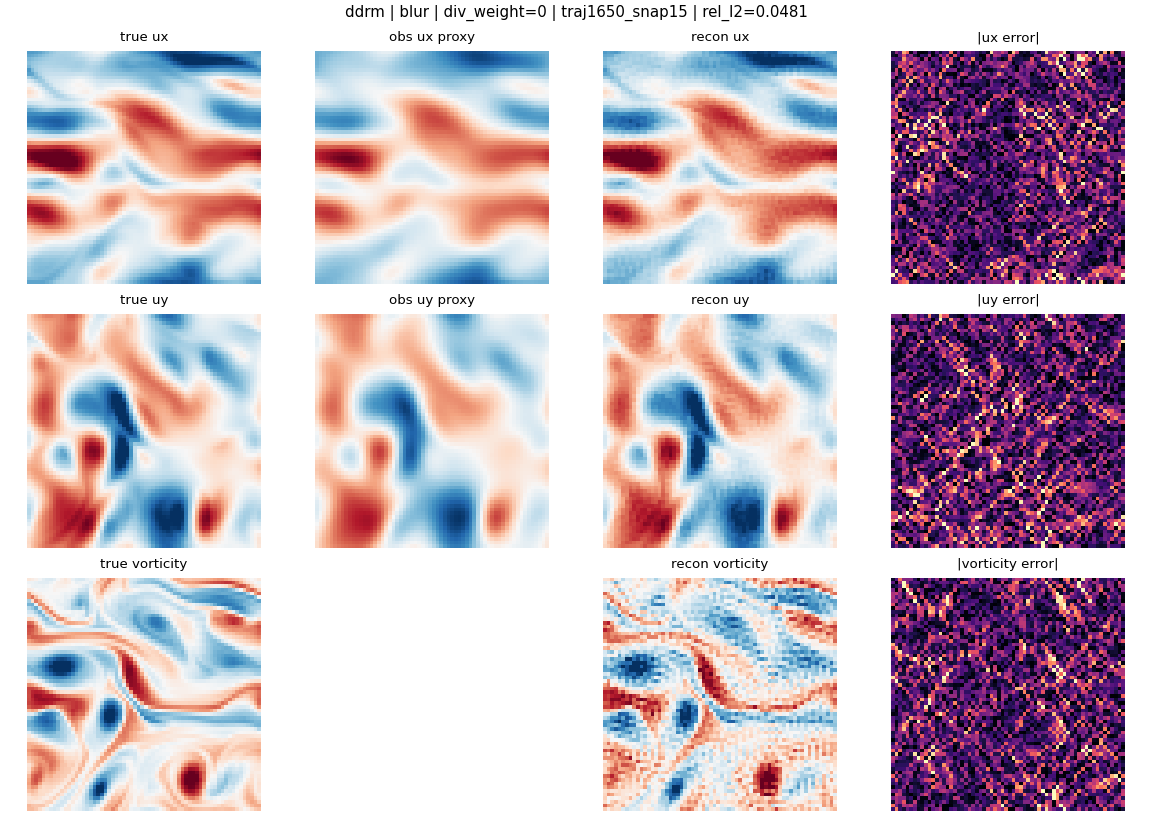

runs_ddrm_colab/ddrm_blur_eta0p0_n16_steps128_sigma2p0/figures/0006_traj1713_snap12.png


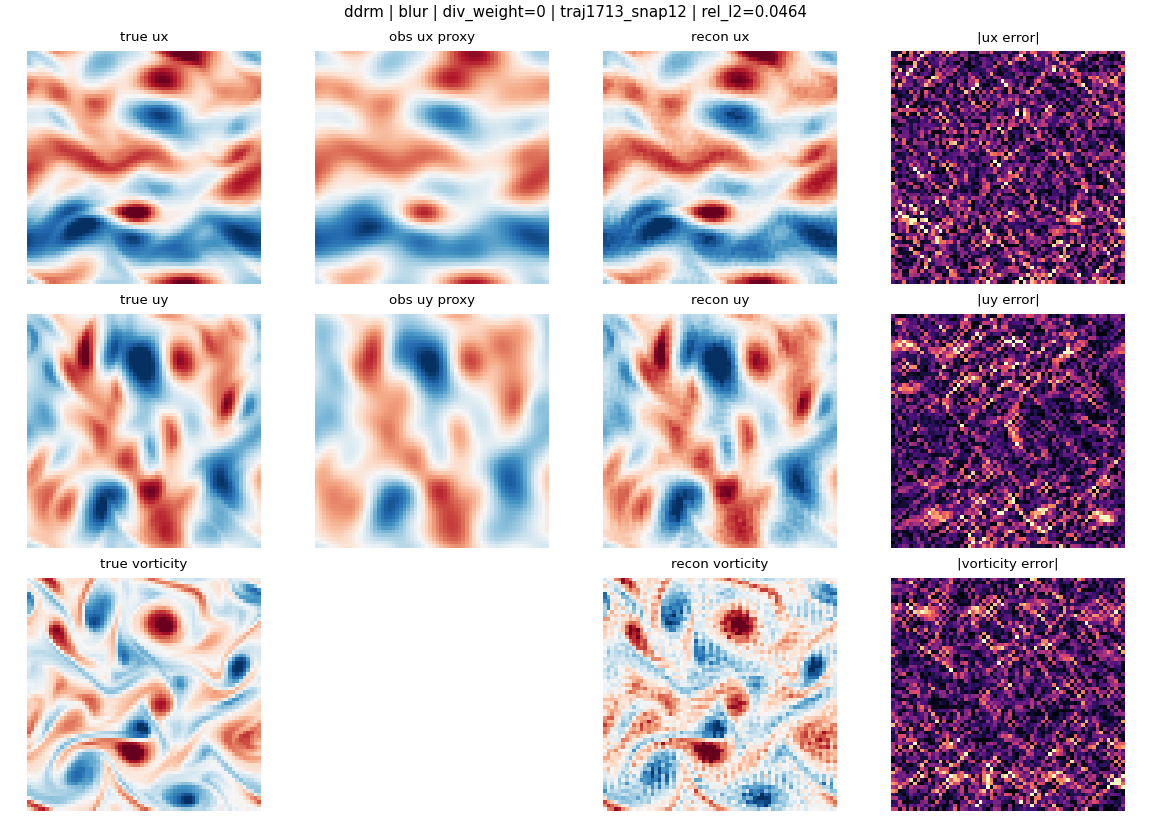

runs_ddrm_colab/ddrm_blur_eta0p0_n16_steps128_sigma2p0/figures/0007_traj1651_snap33.png


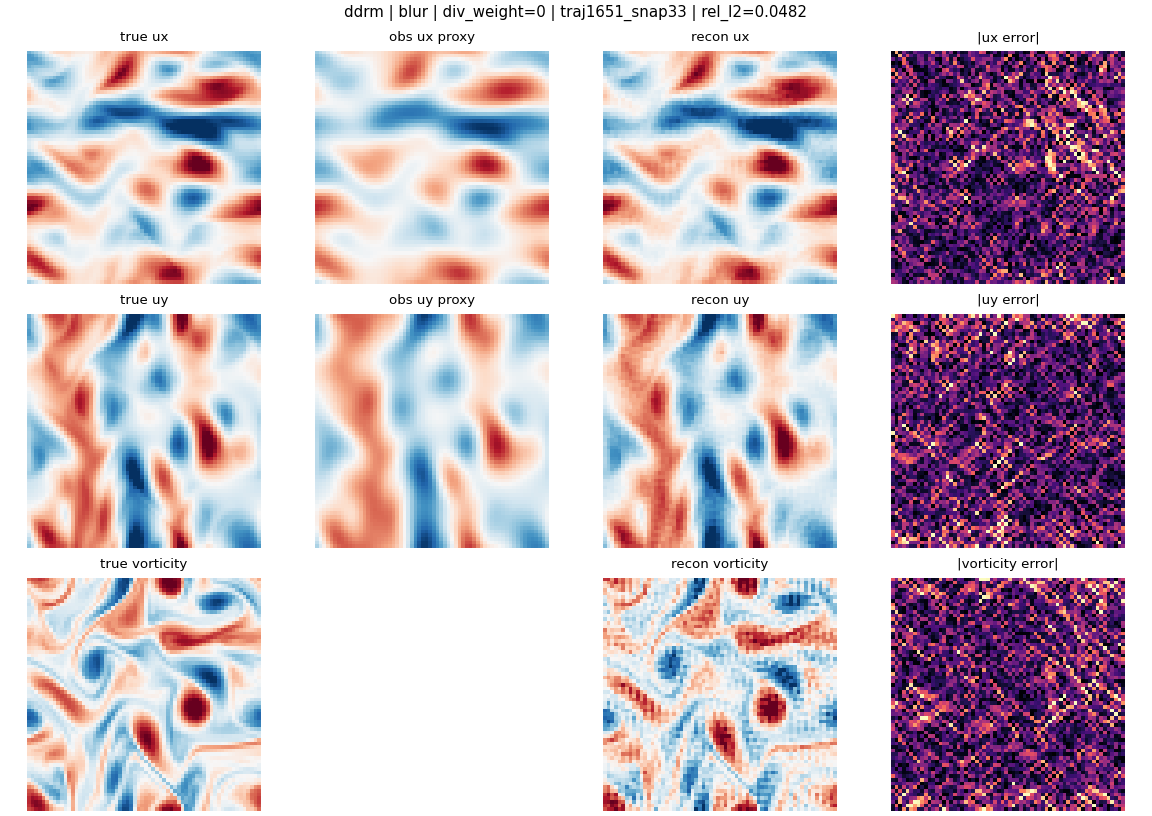

In [12]:
#@title Run blur observation
blur_metrics_paths = run_ddrm_experiment(
    "blur",
    BLUR_RUNS,
    metric_sample_count=BLUR_METRIC_SAMPLE_COUNT,
    visualization_sample_count=BLUR_VISUALIZATION_SAMPLE_COUNT,
    max_visualizations=BLUR_MAX_VISUALIZATIONS,
    corruption_seed=BLUR_CORRUPTION_SEED,
    noise_sigma=BLUR_NOISE_SIGMA,
    blur_sigma=BLUR_OBS_SIGMA,
    steps=BLUR_DDRM_STEPS,
    run_batch_size=BLUR_RUN_BATCH_SIZE,
)


In [13]:
#@title Full val eval (optional)
RUN_FULL_VAL_EVAL = False  #@param {type:"boolean"}
FULL_VAL_RUN_BATCH_SIZE = RUN_BATCH_SIZE * 4  #@param {type:"integer"}
FULL_VAL_METRIC_SAMPLE_COUNT = FULL_VAL_RUN_BATCH_SIZE * 5  #@param {type:"integer"}
FULL_VAL_DDRM_STEPS = DDRM_STEPS  #@param {type:"integer"}
FULL_VAL_VISUALIZATION_SAMPLE_COUNT = 0  #@param {type:"integer"}
FULL_VAL_MAX_VISUALIZATIONS = 0  #@param {type:"integer"}
FULL_VAL_DISPLAY_MAX_IMAGES = 0  #@param {type:"integer"}
FULL_VAL_OPERATORS = ["downsample", "blur"]

if RUN_FULL_VAL_EVAL:
    val_public_paths = find_public_paths(DATA_SOURCE, lambda name: name.startswith("val_") and name.endswith(".npz"))
    if not val_public_paths:
        print("WARNING: no val_*.npz files found; using single val shard.")
        val_public_paths = [val_public_path]
    print("full-val shards:", len(val_public_paths))
    FULL_VAL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    for public_path in val_public_paths:
        filename = Path(public_path).name
        target = FULL_VAL_CACHE_DIR / filename
        download_file(yandex_download_href(DATA_SOURCE, public_path), target, filename)

    full_val_jobs = {
        "downsample": (DOWN_RUNS, DOWN_CORRUPTION_SEED, DOWN_NOISE_SIGMA, BLUR_SIGMA),
        "blur": (BLUR_RUNS, BLUR_CORRUPTION_SEED, BLUR_NOISE_SIGMA, BLUR_OBS_SIGMA),
    }
    full_val_metrics_paths = []
    for operator_name in FULL_VAL_OPERATORS:
        run_specs, corruption_seed, noise_sigma, blur_sigma = full_val_jobs[operator_name]
        full_val_metrics_paths.extend(run_ddrm_experiment(
            operator_name,
            run_specs,
            metric_sample_count=FULL_VAL_METRIC_SAMPLE_COUNT,
            visualization_sample_count=FULL_VAL_VISUALIZATION_SAMPLE_COUNT,
            max_visualizations=FULL_VAL_MAX_VISUALIZATIONS,
            corruption_seed=corruption_seed,
            noise_sigma=noise_sigma,
            blur_sigma=blur_sigma,
            steps=FULL_VAL_DDRM_STEPS,
            run_batch_size=FULL_VAL_RUN_BATCH_SIZE,
            data_source_dir=FULL_VAL_CACHE_DIR,
            data_tag="full_val",
            display_max_images=FULL_VAL_DISPLAY_MAX_IMAGES,
        ))
else:
    print("Skipping full-val eval. Set RUN_FULL_VAL_EVAL=True for final metrics.")


Skipping full-val eval. Set RUN_FULL_VAL_EVAL=True for final metrics.


In [14]:
#@title Final combined CSV
if not all_metrics_by_run:
    raise RuntimeError("No metrics yet. Run at least one observation cell first.")

frames = []
for path in all_metrics_by_run.values():
    df = pd.read_csv(path)
    df["run"] = str(path.parent)
    frames.append(df)
all_metrics = pd.concat(frames, ignore_index=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)
all_csv = RUNS_DIR / "all_metrics.csv"
all_metrics.to_csv(all_csv, index=False)

group_cols = [col for col in ["method_variant", "method", "physics_informed", "physics_projection", "operator", "run"] if col in all_metrics.columns]
summary = all_metrics.groupby(group_cols)[["rel_l2", "rmse", "measurement_error", "divergence", "vorticity_rmse"]].mean().reset_index()
summary_csv = RUNS_DIR / "summary.csv"
summary.to_csv(summary_csv, index=False)
display(summary)
print("all metrics:", all_csv)
print("summary:", summary_csv)


,method_variant,method,physics_informed,physics_projection,operator,run,rel_l2,rmse,measurement_error,divergence,vorticity_rmse
0,ddrm,ddrm,0,0,blur,runs_ddrm_colab/ddrm_blur_eta0p0_n16_steps128_...,0.049399,0.018447,0.000020,0.130881,0.054274
1,ddrm,ddrm,0,0,downsample,runs_ddrm_colab/ddrm_downsample_eta0p0_n16_ste...,0.065514,0.024708,0.000032,0.019684,0.043141


all metrics: runs_ddrm_colab/all_metrics.csv
summary: runs_ddrm_colab/summary.csv


## Parameter guide

Each operator has a configure/run cell pair. Change settings in the configure cell, then run.

- `METRIC_SAMPLE_COUNT`: val samples for metrics. 16 for debug, 256 for final.
- `VISUALIZATION_SAMPLE_COUNT` / `VISUALIZATION_SEED`: keep fixed across team members for reproducible PNGs.
- `RUN_BATCH_SIZE`: GPU batch size. A100 default is 32; reduce to 16 or 8 if OOM.
- `eta`: DDRM stochasticity per step. `0.0` is deterministic and is the default for stable metrics; increase only for diversity experiments.
- `measurement_sigma`: assumed noise level on observation `y`. Keep `0.0` when `NOISE_SIGMA=0.0`; increase only for noisy observations.
- `physics_projection`: if True, applies Helmholtz div-free projection to `pred_x0` after DDRM spectral update, enforcing `div(u) = 0`.
- `BLUR_SIGMA`: Gaussian blur kernel width in grid cells. Default `2.0` for a less ill-posed sanity run.
- `RUN_FULL_VAL_EVAL`: downloads all `val_*.npz` shards for final evaluation. Leave False during development.

DDRM is only used for `downsample` and `blur`. Blur uses Fourier correction; downsample uses block-mean projection. For sparse/mask operators use the DPS or DDNM notebooks.

Results are saved under `runs_ddrm_colab/`. The final cell writes `all_metrics.csv` and `summary.csv`.
